In [1]:
import torch
import gpytorch
import pandas as pd
import pickle
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from torch.utils.data import TensorDataset, DataLoader
from pyproj import Transformer
from sklearn.metrics import pairwise_distances
from scipy.interpolate import RegularGridInterpolator
from torch_geometric.data import Data




/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [23]:

with open("analysis_dataset_enriched.p", "rb") as f:
  df_processed_enriched = pickle.load(f)

In [3]:
df_processed_enriched['sensor_index'].nunique()

43

In [5]:
expected_counts = df_processed_enriched.groupby('sensor_index').apply(
    lambda g: (g['date'].max() - g['date'].min()).days + 1
)
actual_counts = df_processed_enriched.groupby('sensor_index')['date'].count()

missing_report = pd.DataFrame(
    {'expected': expected_counts, 'actual': actual_counts}
)
missing_report['missing_days'] = (
    missing_report['expected'] - missing_report['actual']
)
print(missing_report[missing_report['missing_days'] > 0])

Empty DataFrame
Columns: [expected, actual, missing_days]
Index: []


In [ ]:
#now connect the sensors into a air monitoring network. 

In [6]:
df_processed_enriched.head(5)

,sensor_index,date,pm25_epa_corrected,latitude,longitude,temperature_2m_max,temperature_2m_min,temperature_2m_mean,relative_humidity_2m_mean,precipitation_sum,...,et0_fao_evapotranspiration,windspeed_10m_mean,winddirection_10m_prevailing,major_roads_count_3km,urban_landuse_area_m2_3km,building_footprint_area_3km,green_space_area_3km,total_road_length_3km,railway_length_3km,elevation_m
0,5330,2021-06-12,30.116,36.80372,126.93623,28.7,17.7,21.9,83,0.0,...,4.73,5.919843,4.877802,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0,24.0
1,5330,2021-06-26,20.636,36.80372,126.93623,26.0,20.4,22.2,82,4.1,...,3.28,2.412766,50.944546,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0,24.0
2,5330,2021-05-19,29.206,36.80372,126.93623,25.0,10.2,17.9,69,0.0,...,4.93,2.605699,342.812818,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0,24.0
3,5330,2021-06-25,21.796,36.80372,126.93623,27.3,17.9,22.4,78,0.2,...,4.31,2.412209,254.489263,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0,24.0
4,5330,2021-04-17,9.432,36.80372,126.93623,13.4,5.3,8.8,63,0.2,...,2.90,8.958965,271.374110,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0,24.0


In [9]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import squareform
from scipy.stats import pearsonr

# 1. Pivot data to align time-series per sensor
pivot_df = df_processed_enriched.pivot(
    index="date", columns="sensor_index", values="pm25_epa_corrected"
)

# 2. Extract unique sensor coordinates matching the pivot columns
sensor_coords = (
    df_processed_enriched[["sensor_index", "latitude", "longitude"]]
    .drop_duplicates("sensor_index")
    .set_index("sensor_index")
    .reindex(pivot_df.columns)
)

# 3. Compute Geographic Distance Matrix (Haversine formula in km)
coords_rad = np.radians(sensor_coords[["latitude", "longitude"]].values)


def compute_haversine_matrix(coords):
  lat1, lon1 = coords[:, 0], coords[:, 1]
  dlat = lat1[:, np.newaxis] - lat1
  dlon = lon1[:, np.newaxis] - lon1
  a = (
      np.sin(dlat / 2.0) ** 2
      + np.cos(lat1[:, np.newaxis]) * np.cos(lat1) * np.sin(dlon / 2.0) ** 2
  )
  c = 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))
  return c * 6371.0  # Earth radius in km


geo_dist_matrix = compute_haversine_matrix(coords_rad)

# 4. Compute Temporal Dissimilarity Matrix (1 - Pearson Correlation)
corr_matrix = pivot_df.corr(method="pearson").values
corr_matrix = np.nan_to_num(
    corr_matrix, nan=0.0
)  # Handle any missing overlaps safely
temp_dist_matrix = 1.0 - corr_matrix  # Higher correlation = lower dissimilarity

# 5. Extract lower triangles for matrix comparison
n_sensors = geo_dist_matrix.shape[0]
i_lower = np.tril_indices(n_sensors, k=-1)
x = geo_dist_matrix[i_lower]
y = temp_dist_matrix[i_lower]

# Filter out invalid entries
valid = ~np.isnan(x) & ~np.isnan(y)
x, y = x[valid], y[valid]

# 6. Execute Mantel Permutation Test
observed_r, _ = pearsonr(x, y)


def run_mantel_test(geo_sq, temp_sq, observed_r, permutations=999, seed=42):
  n = geo_sq.shape[0]
  i_tril = np.tril_indices(n, k=-1)
  x_flat = geo_sq[i_tril]

  count = 0
  rng = np.default_rng(seed) if hasattr(np, "default_rng") else np.random.default_rng(seed)

  for _ in range(permutations):
    perm_idx = rng.permutation(n)
    # Permute rows and columns of the dissimilarity matrix identically
    temp_perm = temp_sq[perm_idx][:, perm_idx]
    y_perm = temp_perm[i_tril]

    r, _ = pearsonr(x_flat, y_perm)
    if abs(r) >= abs(observed_r):
      count += 1

  p_value = (count + 1) / (permutations + 1)
  return observed_r, p_value


mantel_r, p_value = run_mantel_test(
    geo_dist_matrix, temp_dist_matrix, observed_r, permutations=9999
)

print(f"Mantel r (Matrix Correlation): {mantel_r:.4f}")
print(f"Permutation p-value: {p_value:.4f}")

Mantel r (Matrix Correlation): 0.3410
Permutation p-value: 0.0498


In [11]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr


# 1. Map dates to meteorological seasons
def get_season(month):
  if month in [3, 4, 5]:
    return "Spring"
  elif month in [6, 7, 8]:
    return "Summer"
  elif month in [9, 10, 11]:
    return "Autumn"
  else:
    return "Winter"


df_processed_enriched["date"] = pd.to_datetime(df_processed_enriched["date"])
df_processed_enriched["season"] = df_processed_enriched["date"].dt.month.apply(
    get_season
)


# 2. Helper functions for Haversine distance and Mantel test
def compute_haversine_matrix(coords):
  lat1, lon1 = np.radians(coords[:, 0]), np.radians(coords[:, 1])
  dlat = lat1[:, np.newaxis] - lat1
  dlon = lon1[:, np.newaxis] - lon1
  a = (
      np.sin(dlat / 2.0) ** 2
      + np.cos(lat1[:, np.newaxis]) * np.cos(lat1) * np.sin(dlon / 2.0) ** 2
  )
  c = 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))
  return c * 6371.0


def run_mantel_test(geo_sq, temp_sq, observed_r, permutations=999, seed=42):
  n = geo_sq.shape[0]
  i_tril = np.tril_indices(n, k=-1)
  x_flat = geo_sq[i_tril]
  count = 0
  # FIXED: Use np.random.default_rng instead of np.default_rng
  rng = np.random.default_rng(seed)

  for _ in range(permutations):
    perm_idx = rng.permutation(n)
    temp_perm = temp_sq[perm_idx][:, perm_idx]
    y_perm = temp_perm[i_tril]
    r, _ = pearsonr(x_flat, y_perm)
    if abs(r) >= abs(observed_r):
      count += 1
  return (count + 1) / (permutations + 1)


# 3. Iterate through each season and run the analysis
seasonal_results = []

for season, group_df in df_processed_enriched.groupby("season"):
  pivot_df = group_df.pivot(
      index="date", columns="sensor_index", values="pm25_epa_corrected"
  )

  sensor_coords = (
      group_df[["sensor_index", "latitude", "longitude"]]
      .drop_duplicates("sensor_index")
      .set_index("sensor_index")
      .reindex(pivot_df.columns)
  )

  # Clean columns with missing coordinates or all NaNs
  valid_cols = ~sensor_coords.isnull().any(axis=1) & ~pivot_df.isnull().all(
      axis=0
  )
  pivot_df = pivot_df.loc[:, valid_cols]
  sensor_coords = sensor_coords.loc[valid_cols]

  if pivot_df.shape[1] < 3:
    continue

  # Build distance matrices
  coords_arr = sensor_coords[["latitude", "longitude"]].values
  geo_dist = compute_haversine_matrix(coords_arr)

  corr_matrix = pivot_df.corr(method="pearson").values
  corr_matrix = np.nan_to_num(corr_matrix, nan=0.0)
  temp_dist = 1.0 - corr_matrix

  i_lower = np.tril_indices(geo_dist.shape[0], k=-1)
  x = geo_dist[i_lower]
  y = temp_dist[i_lower]
  valid = ~np.isnan(x) & ~np.isnan(y)

  if valid.sum() < 3:
    continue

  observed_r, _ = pearsonr(x[valid], y[valid])
  p_value = run_mantel_test(geo_dist, temp_dist, observed_r, permutations=999)

  seasonal_results.append({
      "season": season,
      "mantel_r": observed_r,
      "p_value": p_value,
  })

# 4. Output summary table
results_df = pd.DataFrame(seasonal_results)
print(results_df.to_string(index=False))

season  mantel_r  p_value
Autumn  0.448067    0.016
Spring  0.365512    0.014
Summer  0.314237    0.053
Winter  0.357596    0.042


In [12]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# 1. Define the Exponential Decay Model
def exp_decay(d, A, L, C0):
    return C0 + A * np.exp(-d / L)

# 2. Setup storage
cutoff_results = []
season_fits = {}

# 3. Iterate through seasons
for season, group_df in df_processed_enriched.groupby("season"):
    # Pivot and Prep
    pivot_df = group_df.pivot(index="date", columns="sensor_index", values="pm25_epa_corrected")
    coords = group_df[["sensor_index", "latitude", "longitude"]].drop_duplicates("sensor_index").set_index("sensor_index").reindex(pivot_df.columns)
    
    # Filter NaNs
    valid_cols = ~coords.isnull().any(axis=1) & ~pivot_df.isnull().all(axis=0)
    pivot_df, coords = pivot_df.loc[:, valid_cols], coords.loc[valid_cols]
    
    if pivot_df.shape[1] < 10: continue # Need enough sensors for a stable fit

    # Matrices
    geo_dist = compute_haversine_matrix(coords[["latitude", "longitude"]].values)
    corr_matrix = pivot_df.corr(method="pearson").values
    
    # Flatten
    i_lower = np.tril_indices(geo_dist.shape[0], k=-1)
    x = geo_dist[i_lower]
    y = corr_matrix[i_lower]
    
    # Clean non-finite
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    
    # Fit Curve (Guessing initial params: A=0.5, L=100km, C0=0)
    try:
        popt, _ = curve_fit(exp_decay, x, y, p0=[0.5, 100, 0], bounds=(0, [1, 1000, 1]))
        A, L, C0 = popt
        cutoff_results.append({"season": season, "distance_cutoff_km": round(L, 2)})
        season_fits[season] = popt
    except RuntimeError:
        continue

# 4. Results
cutoff_df = pd.DataFrame(cutoff_results)
print("Optimal Distance Cutoffs per Season:")
print(cutoff_df.to_string(index=False))

Optimal Distance Cutoffs per Season:
season  distance_cutoff_km
Autumn              427.99
Spring               64.74
Summer               78.73
Winter               70.21


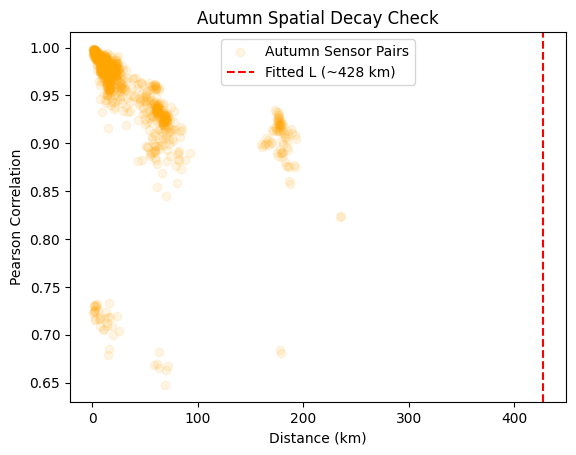

In [13]:
import matplotlib.pyplot as plt

# Quick visualization for Autumn
plt.scatter(x, y, alpha=0.1, color="orange", label="Autumn Sensor Pairs")
plt.axvline(
    427.99, color="red", linestyle="--", label="Fitted L (~428 km)"
)
plt.xlabel("Distance (km)")
plt.ylabel("Pearson Correlation")
plt.title("Autumn Spatial Decay Check")
plt.legend()
plt.show()

In [18]:
#take the data and preprocess the features to create a differential field. 

df_processed_enriched.head(1)

,sensor_index,date,pm25_epa_corrected,latitude,longitude,temperature_2m_max,temperature_2m_min,temperature_2m_mean,relative_humidity_2m_mean,precipitation_sum,...,windspeed_10m_mean,winddirection_10m_prevailing,major_roads_count_3km,urban_landuse_area_m2_3km,building_footprint_area_3km,green_space_area_3km,total_road_length_3km,railway_length_3km,elevation_m,season
0,5330,2021-06-12,30.116,36.80372,126.93623,28.7,17.7,21.9,83,0.0,...,5.919843,4.877802,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0,24.0,Summer


In [24]:

# 1. Ensure date format is strictly YYYY-MM-DD string
df_processed_enriched["date"] = pd.to_datetime(
    df_processed_enriched["date"]
).dt.strftime("%Y-%m-%d")

# 2. List of predictor variables to compute anomalies for
predictor_cols = [
    "pm25_epa_corrected",
    "temperature_2m_max",
    "temperature_2m_min",
    "temperature_2m_mean",
    "relative_humidity_2m_mean",
    "precipitation_sum",
    "windgusts_10m_max",
    "surface_pressure_mean",
    "et0_fao_evapotranspiration",
    "windspeed_10m_mean",
]

# 3. Compute the daily spatial mean across all sensors for each predictor
daily_spatial_means = df_processed_enriched.groupby("date")[
    predictor_cols
].transform("mean")

# 4. Create new anomaly features (Observed Value - Daily Spatial Mean)
# Keeping both raw and anomaly features is generally recommended for GNNs,
# but you can overwrite them if you prefer to drop the absolute values.
for col in predictor_cols:
  anomaly_col_name = f"{col}_anomaly"
  df_processed_enriched[anomaly_col_name] = (
      df_processed_enriched[col] - daily_spatial_means[col]
  )

# Example verification for temperature_2m_mean
df_processed_enriched.head(10)

,sensor_index,date,pm25_epa_corrected,latitude,longitude,temperature_2m_max,temperature_2m_min,temperature_2m_mean,relative_humidity_2m_mean,precipitation_sum,...,pm25_epa_corrected_anomaly,temperature_2m_max_anomaly,temperature_2m_min_anomaly,temperature_2m_mean_anomaly,relative_humidity_2m_mean_anomaly,precipitation_sum_anomaly,windgusts_10m_max_anomaly,surface_pressure_mean_anomaly,et0_fao_evapotranspiration_anomaly,windspeed_10m_mean_anomaly
0,5330,2021-06-12,30.116,36.80372,126.93623,28.7,17.7,21.9,83,0.0,...,1.757674,-0.139535,0.600000,-0.206977,2.093023,-0.023256,7.004651,4.639535,0.015814,0.749185
1,5330,2021-06-26,20.636,36.80372,126.93623,26.0,20.4,22.2,82,4.1,...,1.730884,0.202326,0.718605,0.360465,-1.279070,-1.969767,-2.779070,4.500000,0.077442,0.282474
2,5330,2021-05-19,29.206,36.80372,126.93623,25.0,10.2,17.9,69,0.0,...,3.271209,0.353488,-0.125581,0.111628,1.232558,0.000000,0.527907,4.711628,0.005116,-0.869933
3,5330,2021-06-25,21.796,36.80372,126.93623,27.3,17.9,22.4,78,0.2,...,1.092930,0.206977,0.532558,0.300000,-0.604651,-0.455814,-3.213953,4.530233,-0.070698,-0.333875
4,5330,2021-04-17,9.432,36.80372,126.93623,13.4,5.3,8.8,63,0.2,...,-0.786465,0.583721,2.209302,0.772093,0.651163,-0.097674,-3.316279,4.990698,0.016512,-0.803515
5,5330,2021-05-31,15.832,36.80372,126.93623,24.3,16.2,19.4,74,6.1,...,-1.645907,-0.316279,0.716279,0.132558,-1.558140,-2.072093,-3.234884,4.562791,0.132093,1.479674
6,5330,2021-06-03,14.542,36.80372,126.93623,22.8,16.8,19.3,86,20.3,...,-0.253721,0.316279,0.441860,0.486047,-1.558140,-2.462791,-5.093023,4.616279,-0.071860,-0.980870
7,5330,2021-05-02,13.646,36.80372,126.93623,16.6,7.8,11.2,71,2.1,...,-1.069116,0.288372,0.809302,0.558140,-2.023256,-0.046512,-1.248837,4.930233,0.166047,-1.123462
8,5330,2021-04-06,38.808,36.80372,126.93623,17.4,5.6,11.0,58,0.0,...,-2.685581,0.606977,0.372093,0.676744,-1.232558,0.000000,-2.197674,4.904651,0.066744,-0.100883
9,5330,2021-04-08,15.874,36.80372,126.93623,16.0,3.8,10.1,58,0.0,...,-1.148093,0.188372,-0.627907,0.120930,-0.837209,0.000000,0.444186,4.958140,0.034651,-0.765288


In [25]:
df_processed_enriched.columns

Index(['sensor_index', 'date', 'pm25_epa_corrected', 'latitude', 'longitude',
       'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
       'relative_humidity_2m_mean', 'precipitation_sum', 'windgusts_10m_max',
       'surface_pressure_mean', 'et0_fao_evapotranspiration',
       'windspeed_10m_mean', 'winddirection_10m_prevailing',
       'major_roads_count_3km', 'urban_landuse_area_m2_3km',
       'building_footprint_area_3km', 'green_space_area_3km',
       'total_road_length_3km', 'railway_length_3km', 'elevation_m',
       'pm25_epa_corrected_anomaly', 'temperature_2m_max_anomaly',
       'temperature_2m_min_anomaly', 'temperature_2m_mean_anomaly',
       'relative_humidity_2m_mean_anomaly', 'precipitation_sum_anomaly',
       'windgusts_10m_max_anomaly', 'surface_pressure_mean_anomaly',
       'et0_fao_evapotranspiration_anomaly', 'windspeed_10m_mean_anomaly'],
      dtype='str')

In [27]:
import networkx as nx
import numpy as np
import pandas as pd

# 1. Ensure date is formatted strictly as YYYY-MM-DD string and datetime exists
df_processed_enriched["date"] = pd.to_datetime(
    df_processed_enriched["date"]
).dt.strftime("%Y-%m-%d")


# 2. Ensure the 'season' column exists
def get_season(month):
  if month in [3, 4, 5]:
    return "Spring"
  elif month in [6, 7, 8]:
    return "Summer"
  elif month in [9, 10, 11]:
    return "Autumn"
  else:
    return "Winter"


if "season" not in df_processed_enriched.columns:
  df_processed_enriched["season"] = (
      pd.to_datetime(df_processed_enriched["date"]).dt.month.apply(get_season)
  )

# 3. Define seasonal distance cutoffs (Autumn replaced with 70.0 km)
seasonal_cutoffs = {
    "Spring": 64.74,
    "Summer": 78.73,
    "Autumn": 70.0,
    "Winter": 70.21,
}

# 4. Predictor variables to generate anomalies for (if not already done)
predictor_cols = [
    "pm25_epa_corrected",
    "temperature_2m_max",
    "temperature_2m_min",
    "temperature_2m_mean",
    "relative_humidity_2m_mean",
    "precipitation_sum",
    "windgusts_10m_max",
    "surface_pressure_mean",
    "et0_fao_evapotranspiration",
    "windspeed_10m_mean",
]

# Compute anomalies if they don't already exist in the dataframe
daily_spatial_means = df_processed_enriched.groupby("date")[
    predictor_cols
].transform("mean")
for col in predictor_cols:
  anomaly_col_name = f"{col}_anomaly"
  if anomaly_col_name not in df_processed_enriched.columns:
    df_processed_enriched[anomaly_col_name] = (
        df_processed_enriched[col] - daily_spatial_means[col]
    )

# 5. Land use, terrain, and other contextual features to include as node attributes
feature_cols = [
    "major_roads_count_3km",
    "urban_landuse_area_m2_3km",
    "building_footprint_area_3km",
    "green_space_area_3km",
    "total_road_length_3km",
    "railway_length_3km",
    "elevation_m",
    "winddirection_10m_prevailing",
]


# Helper: Compute Haversine distance matrix (in km) for all unique sensors
def get_distance_matrix(coords_df):
  lat = np.radians(coords_df["latitude"].values)
  lon = np.radians(coords_df["longitude"].values)

  dlat = lat[:, np.newaxis] - lat
  dlon = lon - lon[:, np.newaxis]
  a = (
      np.sin(dlat / 2.0) ** 2
      + np.cos(lat[:, np.newaxis]) * np.cos(lat) * np.sin(dlon / 2.0) ** 2
  )
  c = 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))
  return c * 6371.0


# Helper: Compute initial bearing matrix between all sensor pairs
def get_bearing_matrix(coords_df):
  lat = np.radians(coords_df["latitude"].values)
  lon = np.radians(coords_df["longitude"].values)

  lat1 = lat[:, np.newaxis]
  lat2 = lat
  dlon = lon - lon[:, np.newaxis]

  x = np.sin(dlon) * np.cos(lat2)
  y = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
  bearing = np.degrees(np.arctan2(x, y))
  return (bearing + 360) % 360


# 6. Extract static metadata and precompute global matrices
sensor_meta = (
    df_processed_enriched[["sensor_index", "latitude", "longitude"]]
    .drop_duplicates("sensor_index")
    .reset_index(drop=True)
)
sensor_indices = sensor_meta["sensor_index"].values
sensor_idx_map = {sid: i for i, sid in enumerate(sensor_indices)}

dist_matrix = get_distance_matrix(sensor_meta)
bearing_matrix = get_bearing_matrix(sensor_meta)

# 7. Build daily directed networks with clean YYYY-MM-DD keys and filtered features
daily_graphs = {}

for date, group in df_processed_enriched.groupby("date"):
  if group.empty:
    continue

  season = group["season"].iloc[0]
  max_dist = seasonal_cutoffs.get(season, 70.0)

  sensor_data = group.set_index("sensor_index")
  G = nx.DiGraph()

  # Add nodes populated ONLY with anomaly features, land-use, and context features
  for sid, row in sensor_data.iterrows():
    node_attrs = {
        "latitude": row.get("latitude", np.nan),
        "longitude": row.get("longitude", np.nan),
    }

    # Pack ONLY the anomaly versions of predictor variables (raw values excluded)
    for col in predictor_cols:
      anomaly_col = f"{col}_anomaly"
      if anomaly_col in row:
        node_attrs[anomaly_col] = row.get(anomaly_col, np.nan)

    # Pack land use, terrain, and environmental context features
    for fcol in feature_cols:
      node_attrs[fcol] = row.get(fcol, np.nan)

    G.add_node(sid, **node_attrs)

  active_sids = sensor_data.index.intersection(sensor_indices)
  active_indices = [sensor_idx_map[sid] for sid in active_sids]

  # Evaluate pairs for directional transport
  for i_idx in active_indices:
    sid_i = sensor_indices[i_idx]
    row_i = sensor_data.loc[sid_i]
    ws_i = row_i.get("windspeed_10m_mean", np.nan)
    wd_i = row_i.get("winddirection_10m_prevailing", np.nan)

    if pd.isna(ws_i) or pd.isna(wd_i):
      continue

    # Wind transport direction (where wind is blowing *towards*)
    wind_to = (wd_i + 180) % 360

    for j_idx in active_indices:
      if i_idx == j_idx:
        continue

      d = dist_matrix[i_idx, j_idx]
      if d > max_dist:
        continue

      # Check angle difference between wind transport vector and sensor bearing
      bearing_ij = bearing_matrix[i_idx, j_idx]
      angle_diff = abs(wind_to - bearing_ij)
      angle_diff = min(angle_diff, 360 - angle_diff)

      if angle_diff <= 30.0:
        weight = ws_i * np.exp(-d / max_dist)
        G.add_edge(
            sid_i,
            sensor_indices[j_idx],
            weight=weight,
            distance=d,
            angle_diff=angle_diff,
        )

  daily_graphs[date] = G

In [29]:
daily_graphs['2021-04-01']

In [ ]:
#now we construct daily networks, using varying spatial connections for each season. 
